In [ ]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from pandas import DataFrame
from analytics.metrics.metric import MetricCalculator
from analytics.metrics.time import TimeMetrics
from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor
from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor

config_path = None
problem_id_col = None
timestamp_col = None
idle_gap = None
break_gap = None
proprocessing_steps = []
link_preprocessing_steps = []

edwards2021_config = {
    "config_path": "sample_data_configs/edwards2021.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [TimeStampToDateTimePreprocessor()],
}

cwo_s19_config = {
    "config_path": "sample_data_configs/cwo_s19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
}

codebench2024_config = {
    "config_path": "sample_data_configs/codebench2024.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],

}

config = codebench2024_config
# config = cwo_s19_config
locals().update(config)

In [55]:
from database.config import PS2DataConfig

spec = PS2Versions.v1_0.load()

data_config = PS2DataConfig.from_yaml(config_path, spec)


In [61]:
from analytics.ps2_dataset import PS2Dataset

dataset = PS2Dataset(spec, data_config)
for step in proprocessing_steps:
    dataset.main_table_preprocessors.insert(0, step)
for step in link_preprocessing_steps:
    dataset.link_table_preprocessors.insert(0, step)

In [36]:
main_table = dataset.get_main_table()
main_table.head()

c:\Users\twprice\Documents\GitHub\ProgSnap2\src\database\reader\csv_reader.py:20: DtypeWarning: Columns (14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,EventID,EventType,Order,SubjectID,CodeStateID,ToolInstances,ServerTimestamp,AssignmentID,ProblemID,CourseID,...,ExecutionID,ProgramInput,ProgramOutput,ProgramErrorOutput,X-ExecutionTime,CompileResult,CompileMessageData,EditType,X-Edit.Inserted,SourceLocation
0,1224181,File.Focus,0,1837898832,NaN,Python 3.8.5,2024-05-12 15:57:04.334,4.070595e+09,9.529734e+07,218908526.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1224182,X-File.Blur,1,1837898832,NaN,Python 3.8.5,2024-05-12 15:57:36.562,4.070595e+09,9.529734e+07,218908526.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1217446,File.Focus,2,1837898832,NaN,Python 3.8.5,2024-05-12 15:59:19.589,4.070595e+09,1.471865e+09,218908526.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1217448,File.Edit,3,1837898832,NaN,Python 3.8.5,2024-05-12 15:59:23.102,4.070595e+09,1.471865e+09,218908526.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Insert,NaN,Text:0
4,1217445,File.Edit,4,1837898832,NaN,Python 3.8.5,2024-05-12 15:59:23.209,4.070595e+09,1.471865e+09,218908526.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Insert,NaN,Text:1


In [48]:
main_table[timestamp_col].iloc[0]

Timestamp('2024-05-12 15:57:04.334000')

In [45]:
student_subset = main_table[Cols.SubjectID].unique()[:50]
mt_subset = main_table[main_table[Cols.SubjectID].isin(student_subset)]

<Axes: ylabel='Frequency'>

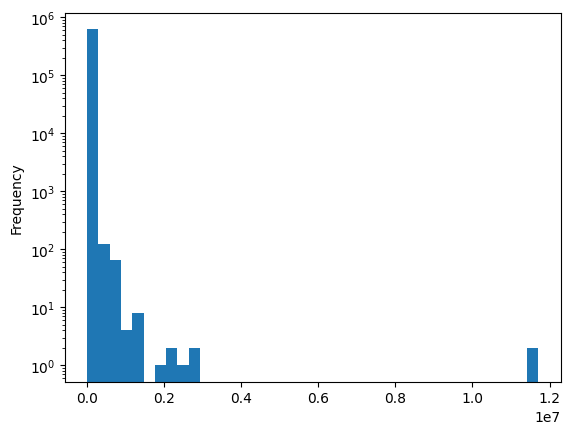

In [47]:
from analytics.metrics.time import TimeMetrics


diffs = TimeMetrics.get_all_diffs(mt_subset, timestamp_col, [Cols.SubjectID, problem_id_col])
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [49]:
TimeMetrics.get_positive_diff_quantiles(mt_subset, timestamp_col, [Cols.SubjectID, problem_id_col]) / 60

# Seems like 5 minutes (90th+ percentile) is a good cutoff for time spent on a problem between submissions
# 30m does seem to suggest that the student is not working on the problem

0.00         0.000017
0.25         0.003200
0.50         0.007150
0.75         0.021017
0.80         0.027267
0.85         0.037850
0.90         0.058600
0.95         0.133383
0.96         0.176433
0.97         0.250433
0.98         0.406333
0.99         0.879262
1.00    195038.207117
Name: DeltaSeconds, dtype: float64

In [51]:
time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

result = main_table.groupby([Cols.SubjectID, problem_id_col]).apply(lambda x: time_metrics.calculate(x))
result

C:\Users\twprice\AppData\Local\Temp\ipykernel_13348\887822383.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = main_table.groupby([Cols.SubjectID, problem_id_col]).apply(lambda x: time_metrics.calculate(x))


ActiveTime  IdleTime  TotalTime  \
SubjectID  ProblemID                                       
13108823   1.076448e+09     279.926   161.617    441.543   
28270295   6.541780e+05    1509.951  1535.863   3045.814   
           1.366278e+07     291.989    92.068    384.057   
           4.811188e+07     132.812   116.259    249.071   
           4.868418e+07     180.852     0.000    180.852   
...                             ...       ...        ...   
4275215466 3.992115e+09     792.867   770.138   1563.005   
           4.093784e+09     117.353    33.494    150.847   
           4.190502e+09       0.000     0.000      0.000   
           4.233866e+09     432.052   267.101    699.153   
4278906896 3.902795e+09      31.290   265.190    296.480   

                         ActiveTimeAfterCorrect  #Breaks  \
SubjectID  ProblemID                                       
13108823   1.076448e+09                   0.000        0   
28270295   6.541780e+05                   0.000        3   
           1.366278e+07                   0.000        0   
           4.811188e+07                   0.000        0   
           4.868418e+07                   0.000        1   
...                                         ...      ...   
4275215466 3.992115e+09                  33.190        3   
           4.093784e+09                   0.000        0   
           4.190502e+09                   6.598        0   
           4.233866e+09                  66.510        1   
4278906896 3.902795e+09                   0.000        0   

                                      StartTime        FirstCorrectTime  \
SubjectID  ProblemID                                                      
13108823   1.076448e+09 2024-09-14 00:57:47.067                     NaT   
28270295   6.541780e+05 2024-10-23 18:03:22.597 2024-10-23 19:06:19.980   
           1.366278e+07 2024-11-13 17:57:39.903 2024-11-13 18:04:03.960   
           4.811188e+07 2024-10-30 18:22:16.049 2024-10-30 18:26:25.120   
           4.868418e+07 2024-09-11 00:29:34.482 2024-09-11 00:36:04.850   
...                                         ...                     ...   
4275215466 3.992115e+09 2024-11-07 12:45:32.785 2024-11-07 13:27:29.930   
           4.093784e+09 2024-10-03 12:32:23.903 2024-10-03 12:34:54.750   
           4.190502e+09 2024-08-29 13:45:29.050 2024-08-29 13:45:29.050   
           4.233866e+09 2024-09-10 12:46:43.786 2024-09-10 13:01:54.480   
4278906896 3.902795e+09 2024-08-28 15:29:03.260 2024-08-28 15:33:59.740   

                                        EndTime  
SubjectID  ProblemID                             
13108823   1.076448e+09 2024-09-14 01:05:08.610  
28270295   6.541780e+05 2024-10-23 19:06:19.980  
           1.366278e+07 2024-11-13 18:04:03.960  
           4.811188e+07 2024-10-30 18:26:25.120  
           4.868418e+07 2024-09-11 00:36:04.850  
...                                         ...  
4275215466 3.992115e+09 2024-11-07 13:28:12.320  
           4.093784e+09 2024-10-03 12:34:54.750  
           4.190502e+09 2024-09-13 18:22:04.873  
           4.233866e+09 2024-09-11 04:06:52.169  
4278906896 3.902795e+09 2024-08-28 15:33:59.740  

[17024 rows x 8 columns]

In [52]:
result.describe()

,ActiveTime,IdleTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,17024.000000,17024.000000,17024.000000,17024.000000,17024.000000,17024,14972,17024
mean,359.916207,203.303831,563.220038,11.381906,0.796288,2024-09-29 08:43:49.512702720,2024-09-28 15:23:55.444831488,2024-09-30 09:55:13.569132544
min,0.000000,0.000000,0.000000,0.000000,0.000000,2024-05-12 15:57:04.334000,2024-08-20 11:32:25.830000,2024-08-20 11:32:25.830000
25%,44.165000,0.000000,95.651250,0.000000,0.000000,2024-09-10 22:18:27.052750080,2024-09-10 18:35:42.104999936,2024-09-11 14:32:17.797999872
50%,231.844000,83.249000,335.491500,0.000000,0.000000,2024-09-24 19:15:52.484500224,2024-09-23 23:30:35.480000,2024-09-25 14:26:31.630000128
75%,474.022250,265.022750,730.970500,0.000000,1.000000,2024-10-15 15:05:17.038249984,2024-10-14 18:57:19.882499840,2024-10-17 13:32:38.589250048
max,11837.542000,8641.813000,20479.355000,6196.715000,51.000000,2024-11-15 02:16:49.200000,2024-11-15 04:01:00.500000,2024-11-15 06:14:17.030000
std,477.391893,332.587938,768.076905,78.760783,1.661149,NaN,NaN,NaN
